# Khan Academy 3 Month User Retention Analysis

**Author:** Victoria McCray  
**Date:** February 20, 2026

---

## Table of Contents

- [Executive Summary](#executive-summary)
- [Data Overview](#data-overview)
- [Question 1: General Usage Patterns](#question-1-general-usage-patterns)
- [Question 2: Retention Correlates](#question-2-retention-correlates)
- [Question 3: Recommendations & Additional Data Needs](#question-3-recommendations)

---

## Research Questions


We are interested in learning about the behavioral patterns of our users in their first month of
usage, particularly for any leading indicators of longer term engagement with the website. 

**This analysis addresses the following three questions:**

1. What are the general usage patterns and behaviors for these users in their 1st month?
2. Are there any behaviors & usage patterns in the 1st month that correlate with month 3 retention (i.e., choice of learning topic and long term engagement)?
3. What recommendations would you make around how we should think about improving month 3 retention? If you had access to more information, what other data points might you want to have to answer this question?

---

<a id='executive-summary'></a>
# 1. Executive Summary


This analysis examines month 1 behavioral patterns for 7,612 Khan Academy users (January 2021, India) to identify factors associated with month 3 retention.

**Overall retention rate: 10.3%** (782 retained, 6,830 not retained)

**Key findings:**

Most users show minimal engagement. 25% had zero activity in month 1. Among active users, median engagement is just 1 day, 2 sessions, and 2.5 minutes total. Only 12% of active users had 5+ sessions, indicating a long-tail distribution where most users try the platform once and leave.

Retained users show higher engagement across all metrics. They average 1.27 days active vs 0.96 days for non-retained users (p<0.001, 32% difference), 3.69 sessions vs 1.98 sessions (p<0.001, 86% difference), and 21.7 minutes vs 8.3 minutes (p<0.001, 162% difference). Days active shows the strongest correlation with retention (r=0.094), though all correlations are relatively weak.

User characteristics matter. Registered users retain at 18.6% compared to 9.3% for unregistered users (p<0.001, 2x difference). Parents show the highest retention at 22.7%, though the sample is small (n=22). Organic search users, the largest acquisition channel at 59%, have the lowest retention at 9.5%.

**Recommendations:** Test interventions focused on encouraging multi-day engagement in the first week and reducing registration friction after initial positive experiences. These show the strongest associations with retention in the data.


In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

<a id='data-overview'></a>

# Data Overview

This analysis uses three datasets provided by Khan Academy:

``user_data`` (7,612 rows): User attributes including registration status, user type (parent, teacher, learner), geographic location (region, city within India), and acquisition channel (organic search, direct, email, etc.)

``usage_data`` (16,394 rows): Event-level activity data where each row represents a single session or activity. Includes timestamp, duration, activity type (watching, practicing, reading), content information (domain, course, unit), and device/platform details.

``outcome_data`` (7,612 rows): Month 3 retention indicator (binary: retained or not retained) for each user.

The usage data requires aggregation to user level before analysis since multiple events belong to individual users.



In [2]:
# ============================================================
# LOAD DATA
# ============================================================

user_data = pd.read_csv("user_data.csv")
usage_data = pd.read_csv("usage_data.csv")
outcome_data = pd.read_csv("outcome_data.csv")

print("✓ Data loaded successfully")
print(f"  • user_data: {user_data.shape}")
print(f"  • usage_data: {usage_data.shape}")
print(f"  • outcome_data: {outcome_data.shape}")

✓ Data loaded successfully
  • user_data: (7612, 10)
  • usage_data: (16394, 15)
  • outcome_data: (7612, 2)


## Dataset Characteristics

The cohort consists of 7,612 first-time users from January 2021, all located in India across 35 regions and 1,117 cities. The majority (90%) are unregistered learners, with organic search being the primary acquisition channel (59% of users).



In [3]:
user_data.describe()

,user_id,first_use_month,first_use_ts,is_registered_user,user_primary_type,country_cd,region,city,attributed_channel,referer_url
count,7612,7612,7612,7612,7612,7612,7611,7611,7612,5019
unique,7612,1,7601,2,4,1,35,1117,8,379
top,kaid_1172977777831184091024959,2021-01-01 00:00:00,2021-01-29 04:29:51,False,Unregistered Learner,IN,MH,Delhi,organic search,https://www.google.com/
freq,1,7612,2,6828,6828,7612,939,455,4478,4162


In [4]:
usage_data.describe(include='all')

,user_id,usage_date,total_mins,activity,content_type,domain_title,course_title,unit_title,locale,client,device_type,os,is_detected_weekday_7am_3pm,start_time_first_ts,end_time_last_ts
count,16394,16394,16394.000000,16394,16374,14071,14071,13864,16394,16394,16394,16394,16394,16394,16394
unique,5684,31,NaN,5,11,10,172,738,7,2,5,7,2,13874,15240
top,kaid_958006483379771309914809,2021-01-29 00:00:00,NaN,WATCHING,VIDEO,Math,Computer programming,Intro to JS: Drawing & Animation,en,web,Phone,Android,False,2021-01-22 09:24:13,2021-01-22 09:24:17
freq,268,796,NaN,7653,7477,6701,756,516,14955,14380,9129,9609,11678,7,7
mean,NaN,NaN,4.477490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,9.858602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.149225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.956942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.377675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
usage_data.head()

,user_id,usage_date,total_mins,activity,content_type,domain_title,course_title,unit_title,locale,client,device_type,os,is_detected_weekday_7am_3pm,start_time_first_ts,end_time_last_ts
0,kaid_543136637624086966998595,2021-01-06 00:00:00,0.009533,WATCHING,VIDEO,NaN,NaN,NaN,en,web,Desktop Web (Non-Chromebook),Linux / Ubuntu / Other Distributions,False,2021-01-06 09:41:53,2021-01-06 10:13:19
1,kaid_543136637624086966998595,2021-01-06 00:00:00,14.042767,WATCHING,VIDEO,Math,Statistics and probability,Confidence intervals,en,web,Desktop Web (Non-Chromebook),Linux / Ubuntu / Other Distributions,False,2021-01-06 09:41:52,2021-01-06 10:19:17
2,kaid_543136637624086966998595,2021-01-06 00:00:00,3.010483,WATCHING,VIDEO,Math,AP®︎ Statistics,Probability,en,web,Desktop Web (Non-Chromebook),Linux / Ubuntu / Other Distributions,False,2021-01-06 10:00:03,2021-01-06 10:03:05
3,kaid_543136637624086966998595,2021-01-06 00:00:00,0.042133,PRACTICING,EXERCISE,Math,AP®︎ Statistics,Probability,en,web,Desktop Web (Non-Chromebook),Linux / Ubuntu / Other Distributions,False,2021-01-06 10:03:12,2021-01-06 10:03:15
4,kaid_1145703200171210503419649,2021-01-11 00:00:00,4.731283,WATCHING,VIDEO,Science,Physics,"Magnetic forces, magnetic fields, and Faraday'...",en,web,Desktop Web (Non-Chromebook),Mac OS X,False,2021-01-11 20:28:13,2021-01-11 20:32:57


In [6]:
outcome_data.describe(include='all')

,user_id,m3_retained
count,7612,7612.000000
unique,7612,NaN
top,kaid_1061303340925871095830606,NaN
freq,1,NaN
mean,NaN,0.102733
std,NaN,0.303629
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,0.000000


### Aggregate Usage Data to User Level

The usage data is at the event level with 16,394 individual activity records. Since multiple events belong to the same user,  the data can be aggregated to create one summary row per user.

For each user, we calculate:
- **Total time**: Sum of all session durations
- **Days active**: Count of unique dates with activity (measures consistency)
- **Number of sessions**: Count of total activities (measures frequency)
- **Content breadth**: Count of unique topics, courses, and content types explored

This produces 5,684 user-level profiles (down from 16,394 events), representing the 75% of the cohort who had at least one activity in month 1.

In [7]:
# ============================================================
# AGGREGATE USAGE DATA TO USER LEVEL
# ============================================================

# For each user, calculate summary metrics from their month 1 activity
user_activity = usage_data.groupby('user_id').agg({
    'total_mins': 'sum',           # Total time spent
    'usage_date': 'nunique',       # Number of unique days active
    'activity': 'count',           # Total number of sessions/activities
    'domain_title': 'nunique',     # Unique topics explored
    'course_title': 'nunique',     # Unique courses
    'content_type': 'nunique'      # Unique content types (video/exercise/article)
}).reset_index()

# Rename for clarity
user_activity.columns = ['user_id', 'total_mins', 'days_active', 'num_sessions',
                          'unique_topics', 'unique_courses', 'unique_content_types']

print(f"✓ User-level summary created")
print(f"  • Rows: {len(user_activity):,} users (down from {len(usage_data):,} events)")
print(f"\nSample:")
print(user_activity.head())

✓ User-level summary created
  • Rows: 5,684 users (down from 16,394 events)

Sample:
                          user_id  total_mins  days_active  num_sessions  \
0  kaid_1000011729644128754954426   60.623934            1             6   
1  kaid_1000177786902274880977611    0.119167            1             1   
2  kaid_1000230483580645145638409    0.295733            1             2   
3  kaid_1000298010717348530127269    0.700717            1             1   
4  kaid_1000478724730003964744679    0.153550            1             2   

   unique_topics  unique_courses  unique_content_types  
0              1               1                     3  
1              1               1                     1  
2              1               1                     1  
3              1               1                     1  
4              1               1                     1  


### Build Analytic Dataset

Merge three datasets into one master table:
1. User characteristics (demographics, registration, channel)
2. Usage metrics (aggregated activity from month 1)
3. Retention outcome (month 3 retained flag)

Uses left join to keep all 7,612 users. Missing activity values filled with 0 for users with no engagement.

**Output**: 7,612 users × 17 features for analysis.

In [8]:

# Step 2: Merge user_data with activity summary
analytic_df = user_data.merge(user_activity, on='user_id', how='left')

# Step 3: Merge with outcome_data to get retention flag
analytic_df = analytic_df.merge(outcome_data, on='user_id', how='left')

# Step 4: Fill missing activity values with 0
activity_cols = ['total_mins', 'days_active', 'num_sessions', 
                 'unique_topics', 'unique_courses', 'unique_content_types']
analytic_df[activity_cols] = analytic_df[activity_cols].fillna(0)

# Check the result
print(f"Final analytic dataset shape: {analytic_df.shape}")
print(f"\nColumns: {analytic_df.columns.tolist()}")
print(f"\nRetention rate: {analytic_df['m3_retained'].mean():.1%}")
print(f"\nFirst few rows:")
analytic_df.describe()

Final analytic dataset shape: (7612, 17)

Columns: ['user_id', 'first_use_month', 'first_use_ts', 'is_registered_user', 'user_primary_type', 'country_cd', 'region', 'city', 'attributed_channel', 'referer_url', 'total_mins', 'days_active', 'num_sessions', 'unique_topics', 'unique_courses', 'unique_content_types', 'm3_retained']

Retention rate: 10.3%

First few rows:


,total_mins,days_active,num_sessions,unique_topics,unique_courses,unique_content_types,m3_retained
count,7612.000000,7612.000000,7612.000000,7612.000000,7612.000000,7612.000000,7612.000000
mean,9.643192,0.992118,2.153705,0.815160,0.993563,1.036390,0.102733
std,48.116065,1.012439,5.955714,0.573231,0.970778,0.887653,0.303629
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.066217,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,5.926233,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
max,2322.071515,16.000000,268.000000,6.000000,20.000000,7.000000,1.000000


### Calculate Engagement Summary Statistics

To understand typical user behavior, descriptive statistics can be calculated for the following engagement metrics: days active, time spent, sessions, and content exploration.

Summary statistics (mean, median, percentiles) are calculated for all engagement metrics. 

When examining typical behavior patterns, statistics are reported for both the full cohort and for active users separately to understand engagement among those who used the platform.


Engagement is highly skewed. Among active users, the median is 1 day, 2 sessions, and 2.5 minutes total. Only 12% had 5+ sessions and 8% explored multiple topics. The mean (12.9 minutes) is much higher than the median (2.5 minutes) due to a small group of power users. This is a long-tail distribution: most users visit once and leave, while a small segment drives overall engagement.


In [9]:
# === DATA OVERVIEW SUMMARY ===
print("="*60)
print("DATA OVERVIEW")
print("="*60)

print(f"\n Dataset Characteristics:")
print(f"  • Total users: {len(user_data):,}")
print(f"  • Users with activity: {len(user_activity):,} ({len(user_activity)/len(user_data):.1%})")
print(f"  • Total activity events: {len(usage_data):,}")
print(f"  • Cohort: January 2021, India only")
print(f"  • User types: {user_data['user_primary_type'].nunique()} categories")

print(f"\n Activity Patterns:")
print(f"  • Average session length: {usage_data['total_mins'].mean():.1f} minutes")
print(f"  • Most common activity: {usage_data['activity'].mode()[0]} ({(usage_data['activity'] == 'WATCHING').mean():.1%})")
print(f"  • Most popular topic: {usage_data['domain_title'].mode()[0]}")

print(f"\n Retention Overview:")
print(f"  • Month 3 retention rate: {analytic_df['m3_retained'].mean():.1%}")
print(f"  • Retained users: {analytic_df['m3_retained'].sum():,}")
print(f"  • Not retained: {(analytic_df['m3_retained']==0).sum():,}")

DATA OVERVIEW

 Dataset Characteristics:
  • Total users: 7,612
  • Users with activity: 5,684 (74.7%)
  • Total activity events: 16,394
  • Cohort: January 2021, India only
  • User types: 4 categories

 Activity Patterns:
  • Average session length: 4.5 minutes
  • Most common activity: WATCHING (46.7%)
  • Most popular topic: Math

 Retention Overview:
  • Month 3 retention rate: 10.3%
  • Retained users: 782
  • Not retained: 6,830


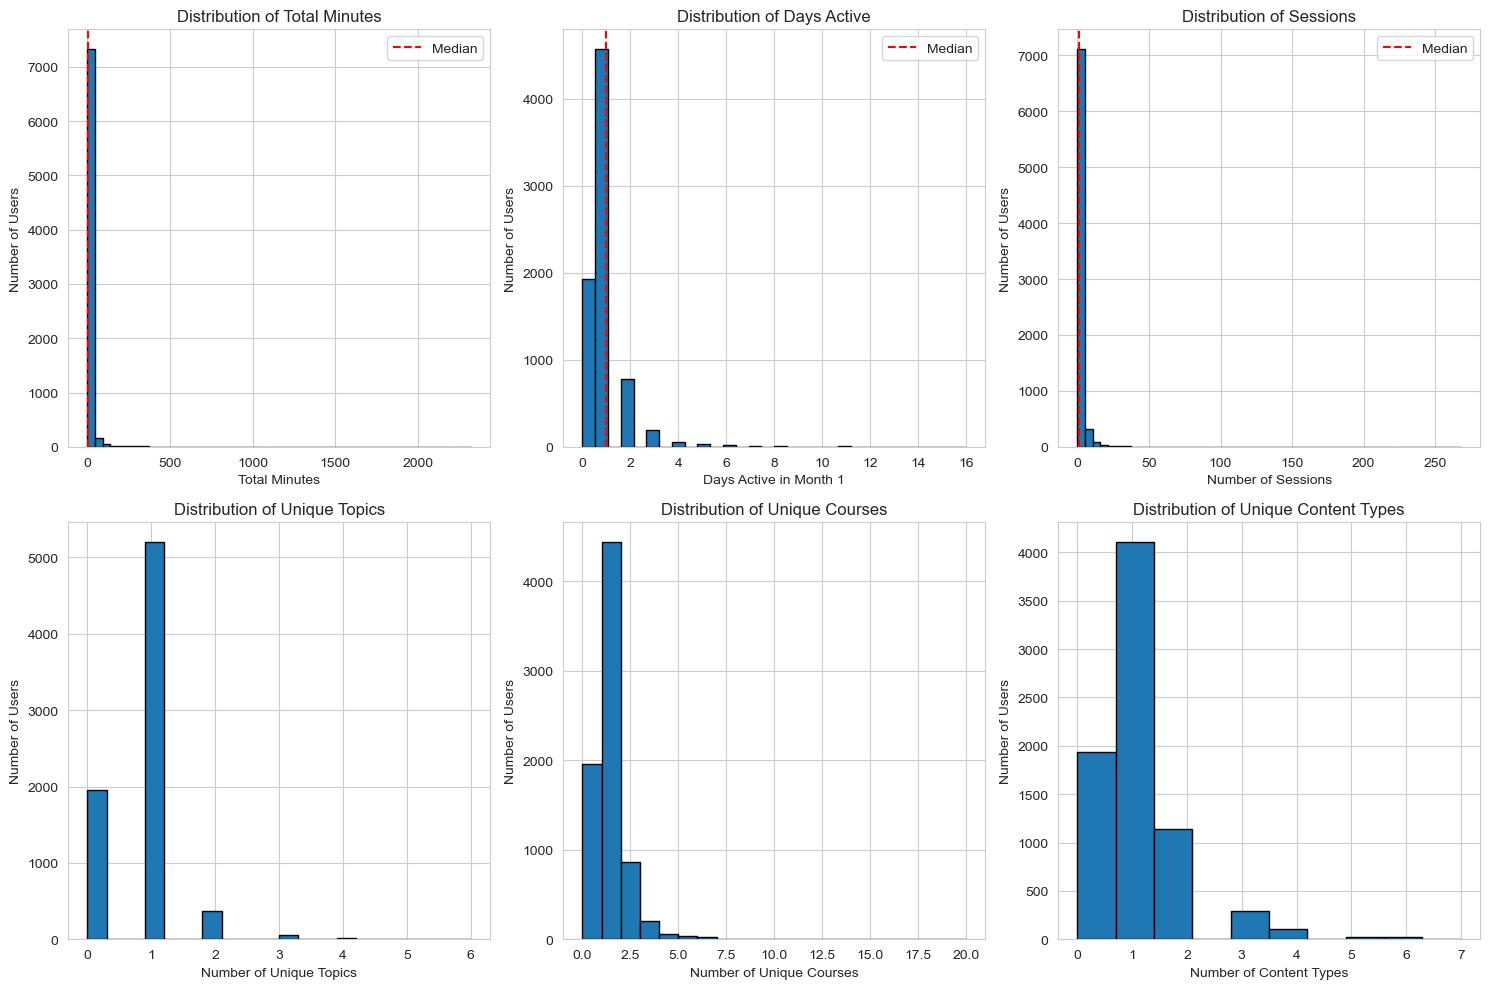

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create subplots for key metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Total minutes
axes[0, 0].hist(analytic_df['total_mins'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Total Minutes')
axes[0, 0].set_xlabel('Total Minutes')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].axvline(analytic_df['total_mins'].median(), color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Days active
axes[0, 1].hist(analytic_df['days_active'], bins=30, edgecolor='black')
axes[0, 1].set_title('Distribution of Days Active')
axes[0, 1].set_xlabel('Days Active in Month 1')
axes[0, 1].set_ylabel('Number of Users')
axes[0, 1].axvline(analytic_df['days_active'].median(), color='red', linestyle='--', label='Median')
axes[0, 1].legend()

# Number of sessions
axes[0, 2].hist(analytic_df['num_sessions'], bins=50, edgecolor='black')
axes[0, 2].set_title('Distribution of Sessions')
axes[0, 2].set_xlabel('Number of Sessions')
axes[0, 2].set_ylabel('Number of Users')
axes[0, 2].axvline(analytic_df['num_sessions'].median(), color='red', linestyle='--', label='Median')
axes[0, 2].legend()

# Unique topics
axes[1, 0].hist(analytic_df['unique_topics'], bins=20, edgecolor='black')
axes[1, 0].set_title('Distribution of Unique Topics')
axes[1, 0].set_xlabel('Number of Unique Topics')
axes[1, 0].set_ylabel('Number of Users')

# Unique courses
axes[1, 1].hist(analytic_df['unique_courses'], bins=20, edgecolor='black')
axes[1, 1].set_title('Distribution of Unique Courses')
axes[1, 1].set_xlabel('Number of Unique Courses')
axes[1, 1].set_ylabel('Number of Users')

# Unique content types
axes[1, 2].hist(analytic_df['unique_content_types'], bins=10, edgecolor='black')
axes[1, 2].set_title('Distribution of Unique Content Types')
axes[1, 2].set_xlabel('Number of Content Types')
axes[1, 2].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

<a id='question-1-general-usage-patterns'></a>
# Question 1: General Usage Patterns

**Research Question:** What are the general usage patterns and behaviors for these users in their 1st month?

**Approach:** The distribution of engagement metrics is analyzed to identify typical versus power user behavior and content exploration patterns.

<a id='engagement-metrics-summary'></a>
## Engagement Metrics Summary

In [11]:
# ============================================================
# QUESTION 1: GENERAL USAGE PATTERNS
# ============================================================

print("="*60)
print("ENGAGEMENT METRICS SUMMARY")
print("="*60)

# Overall engagement
print(f"\n Overall Engagement (All Users, n={len(analytic_df):,}):")
print(f"  • Users with ANY activity: {(analytic_df['num_sessions'] > 0).sum():,} ({(analytic_df['num_sessions'] > 0).mean():.1%})")
print(f"  • Users with NO activity: {(analytic_df['num_sessions'] == 0).sum():,} ({(analytic_df['num_sessions'] == 0).mean():.1%})")

# Filter to active users only for meaningful metrics
active_users = analytic_df[analytic_df['num_sessions'] > 0]

print(f"\n Active Users Only (n={len(active_users):,}):")
print(f"\n  Days Active:")
print(f"    • Mean: {active_users['days_active'].mean():.1f} days")
print(f"    • Median: {active_users['days_active'].median():.0f} day(s)")
print(f"    • Range: {active_users['days_active'].min():.0f} - {active_users['days_active'].max():.0f} days")

print(f"\n  Total Time Spent:")
print(f"    • Mean: {active_users['total_mins'].mean():.1f} minutes")
print(f"    • Median: {active_users['total_mins'].median():.1f} minutes")
print(f"    • 75th percentile: {active_users['total_mins'].quantile(0.75):.1f} minutes")

print(f"\n  Number of Sessions:")
print(f"    • Mean: {active_users['num_sessions'].mean():.1f}")
print(f"    • Median: {active_users['num_sessions'].median():.0f}")
print(f"    • Users with 5+ sessions: {(active_users['num_sessions'] >= 5).sum():,} ({(active_users['num_sessions'] >= 5).mean():.1%})")

print(f"\n  Content Exploration:")
print(f"    • Mean topics explored: {active_users['unique_topics'].mean():.1f}")
print(f"    • Users exploring multiple topics: {(active_users['unique_topics'] > 1).sum():,} ({(active_users['unique_topics'] > 1).mean():.1%})")
print(f"    • Mean courses: {active_users['unique_courses'].mean():.1f}")
print(f"    • Mean content types: {active_users['unique_content_types'].mean():.1f}")

# User segmentation by engagement
print(f"\n User Segmentation by Days Active:")
engagement_segments = pd.cut(analytic_df['days_active'], 
                              bins=[-1, 0, 1, 2, 5, 20], 
                              labels=['No activity', '1 day', '2 days', '3-5 days', '6+ days'])
print(engagement_segments.value_counts().sort_index())

print("\n" + "="*60)

ENGAGEMENT METRICS SUMMARY

 Overall Engagement (All Users, n=7,612):
  • Users with ANY activity: 5,684 (74.7%)
  • Users with NO activity: 1,928 (25.3%)

 Active Users Only (n=5,684):

  Days Active:
    • Mean: 1.3 days
    • Median: 1 day(s)
    • Range: 1 - 16 days

  Total Time Spent:
    • Mean: 12.9 minutes
    • Median: 2.5 minutes
    • 75th percentile: 8.8 minutes

  Number of Sessions:
    • Mean: 2.9
    • Median: 2
    • Users with 5+ sessions: 670 (11.8%)

  Content Exploration:
    • Mean topics explored: 1.1
    • Users exploring multiple topics: 451 (7.9%)
    • Mean courses: 1.3
    • Mean content types: 1.4

 User Segmentation by Days Active:
No activity    1928
1 day          4566
2 days          776
3-5 days        291
6+ days          51
Name: days_active, dtype: int64



### Engagement Patterns

The data shows segmentation patterns:
- **No activity (25%):** 1,928 users in the cohort had zero engagement
- **Single-day users (60%):** 4,566 users visited once and did not return
- **Multi-day users (10%):** 776 users were active 2 days
- **Consistent users (4%):** 342 users were active 3+ days

Most activity is passive. Watching videos accounts for 47% of all activities, while practicing exercises and reading articles are less common. Math is the most popular topic, followed by Science and Computing.

---

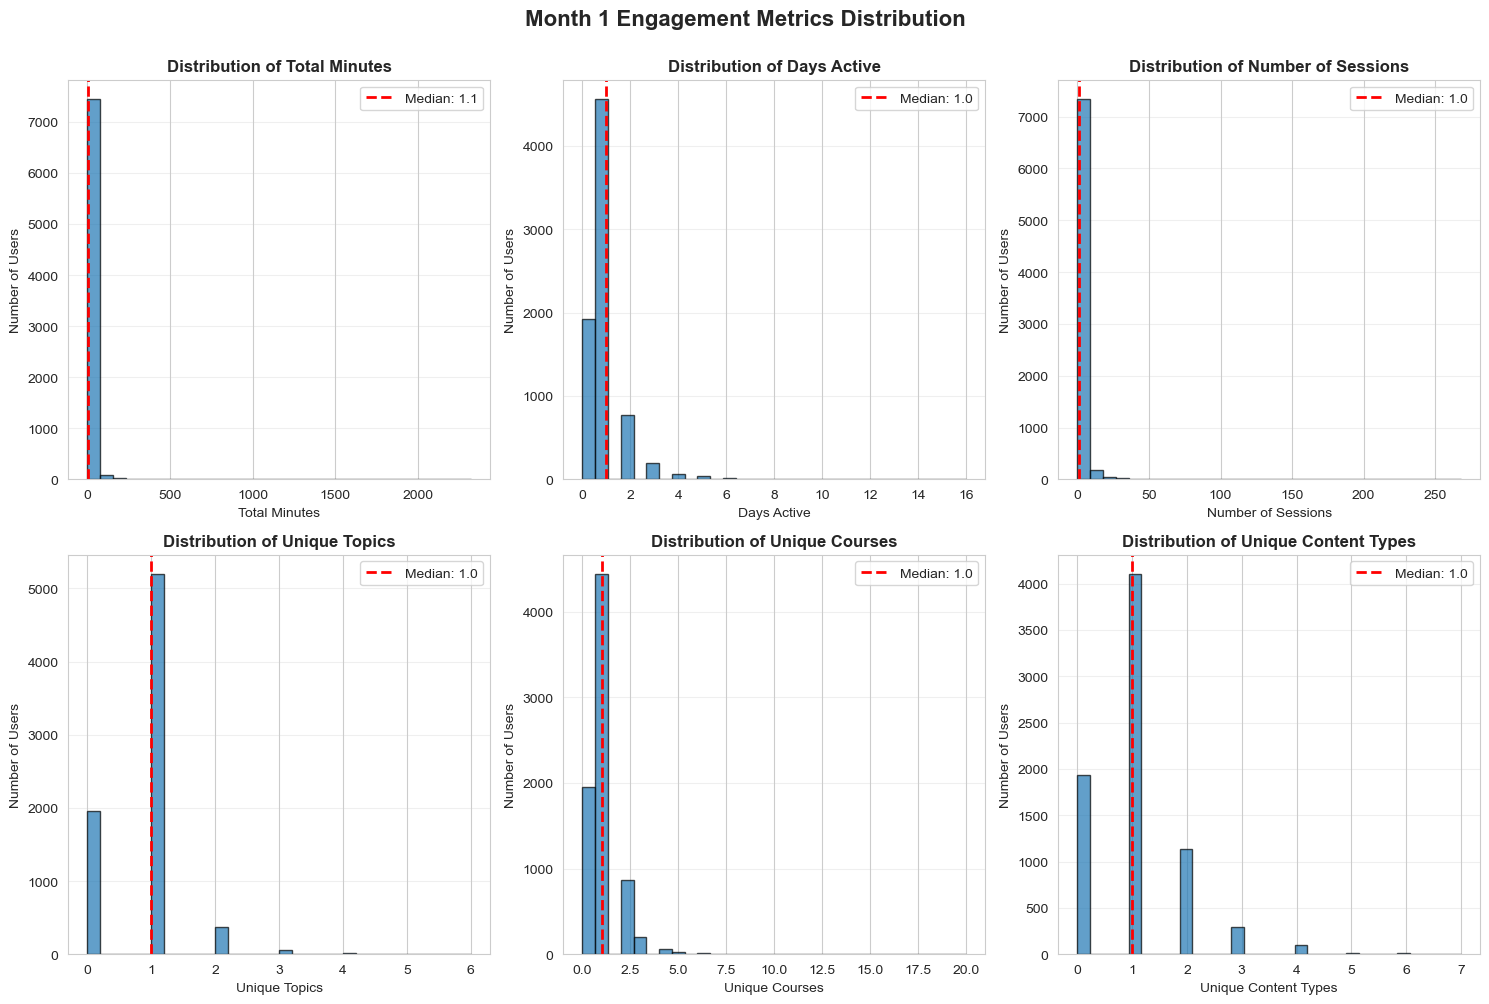

In [12]:
# ============================================================
# VISUALIZATIONS: ENGAGEMENT DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics = ['total_mins', 'days_active', 'num_sessions', 
           'unique_topics', 'unique_courses', 'unique_content_types']
titles = ['Total Minutes', 'Days Active', 'Number of Sessions',
          'Unique Topics', 'Unique Courses', 'Unique Content Types']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 3
    col = idx % 3
    
    # Plot histogram
    axes[row, col].hist(analytic_df[metric], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel('Number of Users')
    
    # Add median line
    median_val = analytic_df[metric].median()
    axes[row, col].axvline(median_val, color='red', linestyle='--', linewidth=2, 
                           label=f'Median: {median_val:.1f}')
    axes[row, col].legend()
    
    # Add grid
    axes[row, col].grid(axis='y', alpha=0.3)

plt.suptitle('Month 1 Engagement Metrics Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("engagement metrics distribution.png")
plt.show()


<a id='key-findings-general-usage-patterns'></a>

## Key Findings: General Usage Patterns

Most users show minimal engagement. 25% of the cohort (1,928 users) had zero activity in month 1. Among active users, the median is just 1 day, 2 sessions, and 2.5 minutes total. 60% of all users were active only a single day and did not return.

Engagement intensity is low. The median active user spent 2.5 minutes, though the mean is 12.9 minutes due to a small group of power users. Only 12% of active users had 5 or more sessions.

Content exploration is narrow. The median user explored 1 topic and 1 course. Only 8% explored multiple topics, suggesting focused, goal-oriented behavior rather than broad exploration.

The distribution shows a large majority with minimal engagement and a small segment of highly engaged users driving overall metrics.

---

<a id='question-2-retention-correlates'></a>
# Question 2: Retention Correlates


**Research Question:** Are there any behaviors and usage patterns in the 1st month that correlate with month 3 retention?

**Approach:** Engagement metrics are compared between retained and non-retained users using t-tests to assess statistical significance. Then, correlations are calculated between behavioral metrics and retention, and analyze retention rates across user attributes (registration status, user type, acquisition channel, primary topic).

---

## Comparative Analysis

The cohort is split into retained (n=782, 10.3%) and not retained (n=6,830, 89.7%) groups and compare their month 1 behavior across key metrics.

---

In [13]:
# ============================================================
# 3.1 COMPARATIVE ANALYSIS: RETAINED VS NOT RETAINED
# ============================================================

# Split users by retention status
retained = analytic_df[analytic_df['m3_retained'] == 1]
not_retained = analytic_df[analytic_df['m3_retained'] == 0]

print("="*60)
print("RETENTION COMPARATIVE ANALYSIS")
print("="*60)

print(f"\n Sample Sizes:")
print(f"  • Retained users: {len(retained):,} ({len(retained)/len(analytic_df):.1%})")
print(f"  • Not retained users: {len(not_retained):,} ({len(not_retained)/len(analytic_df):.1%})")

# Compare key metrics
core_metrics = ['days_active', 'total_mins', 'num_sessions', 
                'unique_topics', 'unique_courses', 'unique_content_types']

comparison_results = []
for metric in core_metrics:
    result = {
        'Metric': metric,
        'Retained (mean)': retained[metric].mean(),
        'Not Retained (mean)': not_retained[metric].mean(),
        'Difference': retained[metric].mean() - not_retained[metric].mean(),
        'Lift (%)': ((retained[metric].mean() / not_retained[metric].mean() - 1) * 100) if not_retained[metric].mean() > 0 else np.inf
    }
    comparison_results.append(result)

comparison_df = pd.DataFrame(comparison_results)

print(f"\n Mean Behavior Comparison:")
print(comparison_df.to_string(index=False))

# Median comparison (less sensitive to outliers)
print(f"\n Median Behavior Comparison:")
for metric in core_metrics:
    ret_median = retained[metric].median()
    not_ret_median = not_retained[metric].median()
    print(f"  {metric:25s}: Retained={ret_median:6.2f}, Not Retained={not_ret_median:6.2f}")

print("\n" + "="*60)

RETENTION COMPARATIVE ANALYSIS

 Sample Sizes:
  • Retained users: 782 (10.3%)
  • Not retained users: 6,830 (89.7%)

 Mean Behavior Comparison:
              Metric  Retained (mean)  Not Retained (mean)  Difference   Lift (%)
         days_active         1.272379             0.960029    0.312349  32.535386
          total_mins        21.678799             8.265176   13.413623 162.290823
        num_sessions         3.685422             1.978331    1.707091  86.289463
       unique_topics         0.843990             0.811859    0.032130   3.957622
      unique_courses         1.225064             0.967057    0.258007  26.679587
unique_content_types         1.143223             1.024158    0.119064  11.625586

 Median Behavior Comparison:
  days_active              : Retained=  1.00, Not Retained=  1.00
  total_mins               : Retained=  1.15, Not Retained=  1.06
  num_sessions             : Retained=  1.00, Not Retained=  1.00
  unique_topics            : Retained=  1.00, Not Ret


## Correlation Analysis

Pearson correlation coefficients quantify the strength of relationships between engagement behaviors and retention. Correlations range from -1 (perfect negative relationship) to +1 (perfect positive relationship), with values near 0 indicating weak or no linear relationship.

## User Attributes Analysis

Beyond behavioral metrics, user characteristics may also relate to retention. This section examines retention rates across categorical variables: registration status, user type, acquisition channel, and primary topic. Chi-square tests assess whether observed differences are statistically significant.

---

In [14]:
# ============================================================
# 3.2 STATISTICAL SIGNIFICANCE TESTING
# ============================================================

print("="*60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

print("\n T-Tests (Comparing Means):")
print("-" * 60)

significance_results = []

for metric in core_metrics:
    retained_vals = retained[metric]
    not_retained_vals = not_retained[metric]
    
    # Perform t-test
    stat, pval = ttest_ind(retained_vals, not_retained_vals)
    
    # Determine significance level
    if pval < 0.001:
        sig = '***'
        sig_level = 'Highly significant'
    elif pval < 0.01:
        sig = '**'
        sig_level = 'Very significant'
    elif pval < 0.05:
        sig = '*'
        sig_level = 'Significant'
    else:
        sig = ''
        sig_level = 'Not significant'
    
    result = {
        'Metric': metric,
        'T-statistic': stat,
        'P-value': pval,
        'Significance': sig,
        'Interpretation': sig_level
    }
    significance_results.append(result)
    
    print(f"\n{metric}:")
    print(f"  Retained: mean={retained_vals.mean():.2f}, std={retained_vals.std():.2f}")
    print(f"  Not Retained: mean={not_retained_vals.mean():.2f}, std={not_retained_vals.std():.2f}")
    print(f"  T-statistic: {stat:.3f}")
    print(f"  P-value: {pval:.6f} {sig}")
    print(f"  → {sig_level}")

significance_df = pd.DataFrame(significance_results)

print("\n" + "="*60)
print("Summary: All metrics with p < 0.05 show statistically significant")
print("differences between retained and not retained users.")
print("="*60)

STATISTICAL SIGNIFICANCE TESTS

 T-Tests (Comparing Means):
------------------------------------------------------------

days_active:
  Retained: mean=1.27, std=1.74
  Not Retained: mean=0.96, std=0.89
  T-statistic: 8.208
  P-value: 0.000000 ***
  → Highly significant

total_mins:
  Retained: mean=21.68, std=111.45
  Not Retained: mean=8.27, std=33.78
  T-statistic: 7.411
  P-value: 0.000000 ***
  → Highly significant

num_sessions:
  Retained: mean=3.69, std=12.93
  Not Retained: mean=1.98, std=4.48
  T-statistic: 7.621
  P-value: 0.000000 ***
  → Highly significant

unique_topics:
  Retained: mean=0.84, std=0.72
  Not Retained: mean=0.81, std=0.55
  T-statistic: 1.485
  P-value: 0.137624 
  → Not significant

unique_courses:
  Retained: mean=1.23, std=1.61
  Not Retained: mean=0.97, std=0.87
  T-statistic: 7.063
  P-value: 0.000000 ***
  → Highly significant

unique_content_types:
  Retained: mean=1.14, std=1.20
  Not Retained: mean=1.02, std=0.84
  T-statistic: 3.556
  P-value: 0.


CORRELATION WITH RETENTION

 Pearson Correlations with Month 3 Retention:
------------------------------------------------------------
days_active              : 0.0937
num_sessions             : 0.0870
total_mins               : 0.0846
unique_courses           : 0.0807
unique_content_types     : 0.0407
unique_topics            : 0.0170


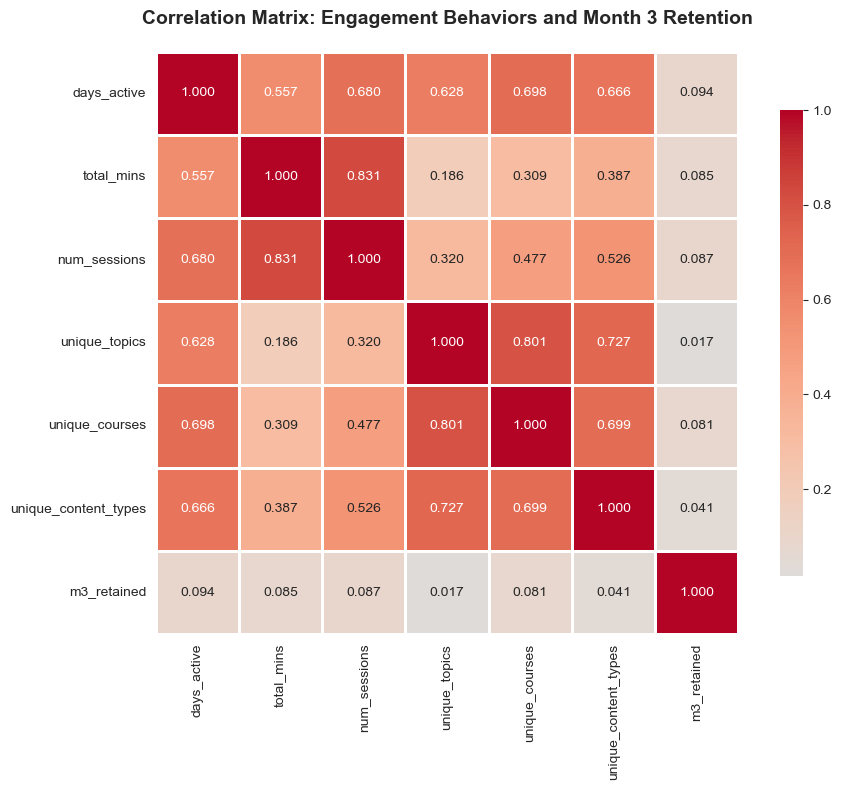

In [15]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

print("\n" + "="*60)
print("CORRELATION WITH RETENTION")
print("="*60)

# Calculate correlations
correlations = analytic_df[core_metrics + ['m3_retained']].corr()['m3_retained'].drop('m3_retained').sort_values(ascending=False)

print("\n Pearson Correlations with Month 3 Retention:")
print("-" * 60)
for metric, corr in correlations.items():
    print(f"{metric:25s}: {corr:6.4f}")

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = analytic_df[core_metrics + ['m3_retained']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Engagement Behaviors and Month 3 Retention', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("behavior correlations with retention.png")
plt.show()


print("\n" + "="*60)

CORRELATIONS WITH MONTH 3 RETENTION
days_active               0.093673
is_registered             0.093184
num_sessions              0.087029
total_mins                0.084645
unique_courses            0.080696
channel_direct            0.050593
unique_content_types      0.040727
unique_topics             0.017019
channel_intra_ka         -0.010062
channel_organic search   -0.030804
Name: m3_retained, dtype: float64


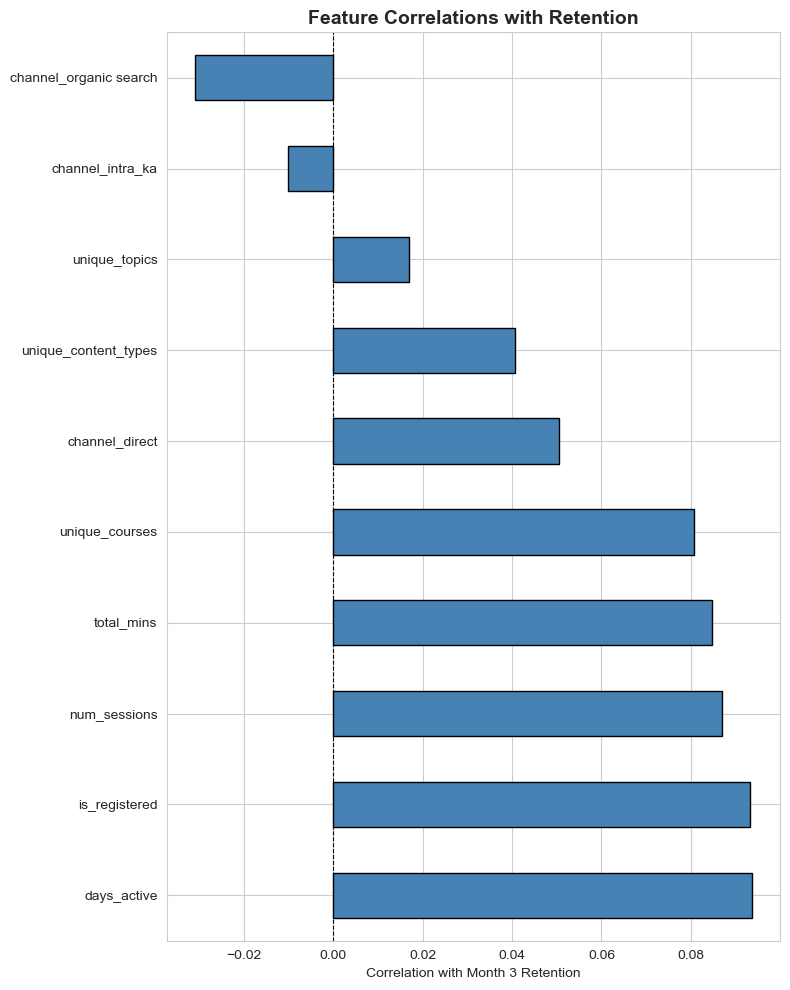

In [16]:
# ============================================================
# QUANTIFIED CATEGORICAL CORRELATION ANALYSIS
# ============================================================

# Create numerical versions of categorical variables
analytic_df['is_registered'] = analytic_df['is_registered_user'].astype(int)

# For categorical with few levels, create dummies
user_type_dummies = pd.get_dummies(analytic_df['user_primary_type'], prefix='user_type')
channel_dummies = pd.get_dummies(analytic_df['attributed_channel'], prefix='channel')

# Combine for correlation
correlation_cols = ['days_active', 'total_mins', 'num_sessions', 
                    'unique_topics', 'unique_courses', 'unique_content_types',
                    'is_registered', 'm3_retained']

# Add top channels
top_channels = analytic_df['attributed_channel'].value_counts().head(3).index
for channel in top_channels:
    analytic_df[f'channel_{channel}'] = (analytic_df['attributed_channel'] == channel).astype(int)
    correlation_cols.append(f'channel_{channel}')

# Calculate correlations
enhanced_correlations = analytic_df[correlation_cols].corr()

# Extract just correlations with retention
retention_correlations = enhanced_correlations['m3_retained'].drop('m3_retained').sort_values(ascending=False)

print("="*60)
print("CORRELATIONS WITH MONTH 3 RETENTION")
print("="*60)
print(retention_correlations)

# Visualize
plt.figure(figsize=(8, 10))
retention_correlations.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Correlation with Month 3 Retention')
plt.title('Feature Correlations with Retention', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig("correlations with retention.png")
plt.show()


In [17]:
# ============================================================
# USER ATTRIBUTES VS RETENTION
# ============================================================

print("="*60)
print("RETENTION BY USER ATTRIBUTES")
print("="*60)

# 1. Registration Status
print("\n1. REGISTRATION STATUS")
print("-" * 60)
reg_retention = analytic_df.groupby('is_registered_user')['m3_retained'].agg(['mean', 'count'])
reg_retention.index = ['Unregistered', 'Registered']
print(reg_retention)
print(f"\nLift: {reg_retention.loc['Registered', 'mean'] / reg_retention.loc['Unregistered', 'mean']:.2f}x")

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(analytic_df['is_registered_user'], analytic_df['m3_retained'])
chi2, pval, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: χ²={chi2:.2f}, p={pval:.4f} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(not significant)'}")

# 2. User Type
print("\n2. USER TYPE")
print("-" * 60)
type_retention = analytic_df.groupby('user_primary_type')['m3_retained'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(type_retention)

# 3. Attribution Channel
print("\n3. ATTRIBUTION CHANNEL")
print("-" * 60)
channel_retention = analytic_df.groupby('attributed_channel')['m3_retained'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(channel_retention)

# 4. Primary Topic (derived)
print("\n4. PRIMARY TOPIC")
print("-" * 60)
# Get each user's primary topic
user_topics = usage_data.groupby('user_id')['domain_title'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'No Activity'
).reset_index()
user_topics.columns = ['user_id', 'primary_topic']

analytic_with_topic = analytic_df.merge(user_topics, on='user_id', how='left')
analytic_with_topic['primary_topic'] = analytic_with_topic['primary_topic'].fillna('No Activity')

topic_retention = analytic_with_topic.groupby('primary_topic')['m3_retained'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(topic_retention)

print("\n" + "="*60)

RETENTION BY USER ATTRIBUTES

1. REGISTRATION STATUS
------------------------------------------------------------
                  mean  count
Unregistered  0.093146   6828
Registered    0.186224    784

Lift: 2.00x
Chi-square: χ²=65.09, p=0.0000 ***

2. USER TYPE
------------------------------------------------------------
                          mean  count
user_primary_type                    
Parent                0.227273     22
Registered Learner    0.193638    723
Unregistered Learner  0.093146   6828
Teacher               0.025641     39

3. ATTRIBUTION CHANNEL
------------------------------------------------------------
                        mean  count
attributed_channel                 
email               0.142857      7
direct              0.125746   2346
website referral    0.115789     95
youtube             0.100000     20
organic search      0.094908   4478
intra_ka            0.090278    432
other KA marketing  0.039216    204
social referral     0.033333     30


**Attribute Patterns**

Registration status shows the clearest difference: registered users retain at double the rate of unregistered users (18.6% vs 9.3%). Among user types, parents show notably higher retention (22.7%) though the sample is small (n=22). Acquisition channel reveals a quality gradient: email (14.3%) and direct traffic (12.6%) retain better than organic search (9.5%), the dominant channel. Topic choice shows minimal variation across subjects (most cluster 8-12%), indicating user characteristics matter more than content selection for retention.

---

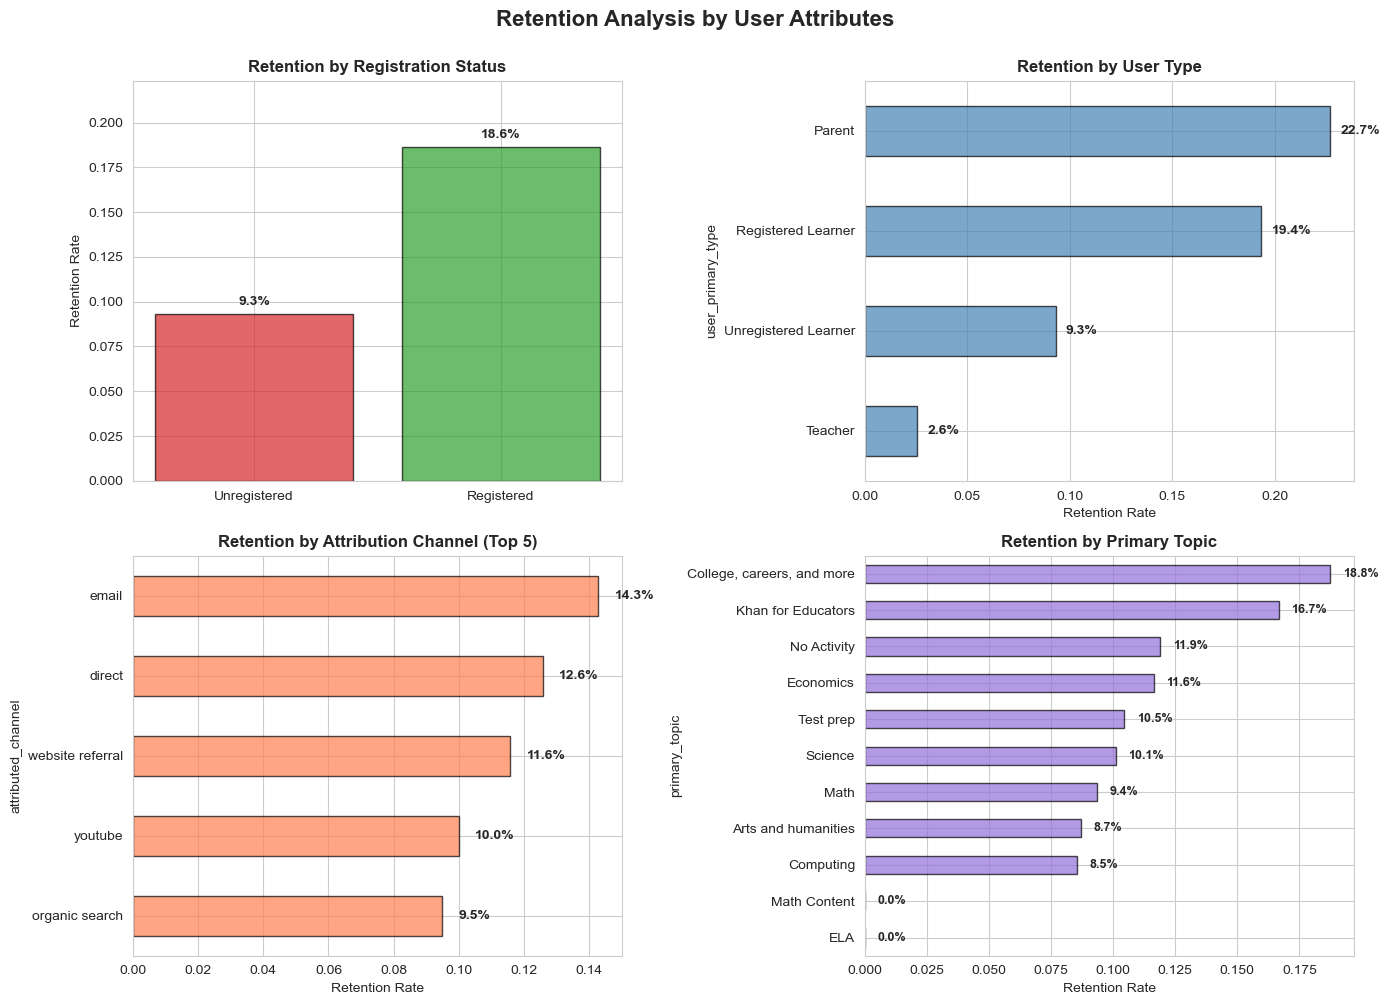

In [18]:
# ============================================================
# VISUALIZE RETENTION BY ATTRIBUTES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Registration Status
ax1 = axes[0, 0]
reg_data = analytic_df.groupby('is_registered_user')['m3_retained'].mean()
bars1 = ax1.bar(['Unregistered', 'Registered'], reg_data, color=['#d62728', '#2ca02c'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Retention Rate')
ax1.set_title('Retention by Registration Status', fontweight='bold')
for i, (bar, val) in enumerate(zip(bars1, reg_data)):
    ax1.text(i, val + 0.005, f'{val:.1%}', ha='center', fontweight='bold')
ax1.set_ylim(0, max(reg_data) * 1.2)

# 2. User Type
ax2 = axes[0, 1]
type_data = analytic_df.groupby('user_primary_type')['m3_retained'].mean().sort_values()
type_data.plot(kind='barh', ax=ax2, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Retention Rate')
ax2.set_title('Retention by User Type', fontweight='bold')
for i, val in enumerate(type_data):
    ax2.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold')

# 3. Attribution Channel (top 5)
ax3 = axes[1, 0]
channel_data = analytic_df.groupby('attributed_channel')['m3_retained'].mean().sort_values().tail(5)
channel_data.plot(kind='barh', ax=ax3, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Retention Rate')
ax3.set_title('Retention by Attribution Channel (Top 5)', fontweight='bold')
for i, val in enumerate(channel_data):
    ax3.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold')

# 4. Primary Topic
ax4 = axes[1, 1]
topic_data = analytic_with_topic.groupby('primary_topic')['m3_retained'].mean().sort_values()
topic_data.plot(kind='barh', ax=ax4, color='mediumpurple', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Retention Rate')
ax4.set_title('Retention by Primary Topic', fontweight='bold')
for i, val in enumerate(topic_data):
    ax4.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Retention Analysis by User Attributes', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("retention by user attributes.png")
plt.show()


<a id='question-3-recommendations'></a>

# Question 3: Recommendations

## Primary Recommendations

### 1. Encourage Multi-Day Engagement

**Finding:** Retained users average 1.27 days active vs 0.96 for non-retained (p<0.001). Days active shows strongest correlation with retention (r=0.094).

**Recommendation:** Test interventions to bring users back within the first week, including personalized email content suggestions after day 1, in-app prompts for return visits, and simple streak tracking ("2 days in a row!"). 

**Rationale:** 60% of users visit once and never return. Even modest improvements in return rates could meaningfully impact retention.

---

### 2. Simplify Registration

**Finding:** Registered users retain at 18.6% vs 9.3% for unregistered (p<0.001). Only 10% of cohort is registered.

**Recommendation:** Prompt registration after first success (video completion, exercise solved) using one-click social login and framing the value as "save your progress" rather than "create account."

**Rationale:** Registration shows a 2x retention difference. While correlation does not indicate causation, this represents a clear opportunity for intervention and testing.

---

### 3. Optimize Acquisition Channel Quality

**Finding:** Organic search accounts for 59% of users (4,478) but has the lowest retention at 9.5%, compared to 12.6% for direct traffic and 14.3% for email.

**Recommendation:** Test targeted interventions for organic search users (immediate relevant content suggestions, early registration prompts) and consider shifting acquisition investment toward higher-quality channels like email and referral partnerships. Monitor channel-specific retention to optimize the acquisition mix over time.

**Rationale:** The largest traffic source shows the weakest retention, likely reflecting lower intent ("homework help" vs "learning journey"). Even small improvements in organic search retention or modest shifts in channel mix could impact overall retention given the volume.

---

### 4. Expand Parent User Segment

**Finding:** Parents retain at 22.7%, the highest overall rate, though they represent only 0.3% of the cohort (n=22).

**Recommendation:** Test parent-specific acquisition strategies and features such as progress dashboards and goal-setting tools for tracking children's learning to grow this high-retention segment.

---


## Additional Data Needs

Additional data would strengthen these recommendations. User intent data (why they came to Khan Academy) would enable better segmentation of interventions for homework help versus learning journey users. Month 2 behavioral data would identify when drop-off occurs and critical intervention windows. Content quality metrics (completion rates, success rates) would reveal which specific materials engage versus frustrate users. Demographics (age, education level) would improve personalization, and goal-setting data would provide additional intervention targets if goals correlate with retention.

---

# Appendix

## Assumptions and Data Treatment

This analysis uses three datasets provided by Khan Academy: user attributes (user_data), event-level activity records (usage_data), and month 3 retention outcomes (outcome_data). Month 1 behavior is defined as activity occurring in January 2021 based on the first_use_month field. Retention is defined as any detected usage in month 3 (binary indicator m3_retained). Event-level usage data was aggregated to user level by summing total_mins, counting unique usage_date values for days active, counting activities for sessions, and counting unique values for content exploration metrics (domain_title, course_title, content_type). Users with zero month 1 activity (25% of cohort) were retained in the analysis with engagement metrics set to 0. Primary topic was assigned based on the most frequent domain_title for each user. The analysis is limited to users from India in a single cohort month, and all correlations are weak (r<0.10), indicating retention is influenced by multiple factors beyond first-month behavior. Small sample sizes for some segments (parents n=22, teachers n=39, email channel n=7) limit the reliability of those specific findings.

---